# Collecting simulated cavity data

We are interested in the dynamic version of cavity ponderomotive instability.

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..', '..'))
sys.path.append(root_dir)

data_dir = f'{root_dir}/data/regimes/cavity_hopf'

import care
import util_data

### Instantiate a cavity resonance simulator

In [2]:
# --! specify cavity parameters --!

parser = care.create_args_parser()

sim_args = parser.parse_args(
    args=[
        '-fg', '1.3e9',                   # operating frequency, Hz
        '-ig', '0.016',                   # forward power equivalent current, A
        '-og', '-471.0',                  # offset from operating frequency, Hz

        '-rc', '1036',                    # R over Q of cavity, Ohm
        '-qc', '3e6',                     # loaded quality factor of cavity, unitless

        '-ga', '12e6',                    # amplifier gain

        '-fm', '280, 341, 460, 487, 618', # frequency of mechanical modes
        '-qm', '20, 20, 30, 20, 80',      # quality of mechanical modes
        '-km', '2, 0.8, 2, 0.6, 0.2',     # coupling of mechanical modes

        '-ts', '1e-6',                    # time step, s
        '-es', '{                 \
            "0":   "rf_on"        \
        }',
    ]
)

sim = care.simulator(sim_args)              # cavity simulator

sim_t = 0.3                                 # simulation time, s
sim_nsample = int(sim_t / sim_args.step_t)  # number of simulation steps
sim_o_downsample = 50                       # downsampling factor for simulated signals


In [3]:
# --! helping functions --!

def run_sim(sim, sim_nsample, ic, downsample=50, kick_force=0, kick_start=0, kick_end=0):
    vc  = np.zeros(sim_nsample, dtype=complex)
    dc  = np.zeros(sim_nsample)

    # --! reset simulator to given initial condition
    sim.reset(ic)

    # --! simulate
    for i in range(sim_nsample):

        # --! implement kick as a tuner action
        a = kick_force if i > kick_start and i < kick_end else 0.0

        # --! perform simulator step
        vc[i], dc[i] = sim.step(a)

    # --! convert simulated signals
    vc = abs(vc) * 1e-6
    dc = dc / 2 / np.pi

    # --! downsample simulated signals
    vc = vc[::downsample]
    dc = dc[::downsample]

    # --! reshape 1d arrays into column vectors
    vc = vc.reshape(-1, 1)
    dc = dc.reshape(-1, 1)

    return vc, dc

def plot_result_timedomain(vc, dc, sim_nsample, dt, downsample):

    t = np.arange(sim_nsample) * dt
    t = t[::downsample]

    plt.figure(figsize=(8, 6))

    plt.subplot(2,1,1)
    plt.plot(t, vc)
    plt.xlabel('Time (s)')
    plt.ylabel('Cavity voltage (MV)')

    plt.subplot(2,1,2)
    plt.plot(t, dc)
    plt.xlabel('Time (s)')
    plt.ylabel('Detuning (Hz)')

    plt.tight_layout()
    plt.show()

def plot_result_phasespace(vcs, dcs, dt):

    plt.figure(figsize=(10, 5))

    plt.subplot(1,2,1)
    plt.plot(dcs[0], vcs[0])
    plt.plot([min(dcs[0]), max(dcs[0])], [0, 0], linestyle='dashed', color='gray')
    plt.plot(dcs[0][0], vcs[0][0], marker='o', color='orange', markersize=8, label='start')
    plt.plot(dcs[0][-1], vcs[0][-1], marker='*', color='orange', markersize=8, label='end')
    plt.xlabel('Detuning (Hz)')
    plt.ylabel('Cavity voltage (MV)')
    plt.legend()

    dc = dcs[0]
    ddc = np.gradient(dc, dt, axis=0)
    dc1 = dc[:len(dc)//2]
    dc2 = dc[-len(dc)//4:]
    ddc1 = ddc[:len(ddc)//2]
    ddc2 = ddc[-len(ddc)//4:]

    plt.subplot(1,2,2)
    plt.plot(dc1, ddc1)
    plt.plot(dc2, ddc2)
    plt.plot(dc1[0], ddc1[0], marker='o', color='green', markersize=8, label='start')
    plt.plot(dc1[-35], ddc1[-35], marker='*', color='green', markersize=10, label='end')
    plt.plot(dc2[0], ddc2[0], marker='o', color='red', markersize=8, label='start')
    plt.plot(dc2[-30], ddc2[-30], marker='*', color='red', markersize=10, label='end')
    plt.xlabel('Detuning (Hz)')
    plt.ylabel('Detuning derivative (s^-2)')
    plt.legend()

    plt.tight_layout()
    plt.show()


### Run simulation

In [4]:
# --! simulation loop to collect data --!

# --! empty lists for cavity voltage and detuning trajectories
vcs = []
dcs = []

# --! specify initial conditions (ics) as a list of initial cavity voltages
ics = [
    0.0   + 1j * 0.0,
    2.5e6 + 1j * 1.5e6,
    2e6   + 1j * 1e6,
    2.5e6 + 1j * 1e6,
    2.5e6 + 1j * 1.5e6,
    3e6   + 1j * 1.55e6,
    3e6   + 1j * 1e6,
    3e6   + 1j * 1.59e6
]

# specify kick parameters: amplitude of kick, sample number of kick start, sample number of kick end
kick_params = [
    (-110.0,  0.15  // sim_args.step_t,  0.2  // sim_args.step_t),
    (-100.0,  0.14  // sim_args.step_t,  0.19 // sim_args.step_t),
    (-115.0,  0.2   // sim_args.step_t,  0.25 // sim_args.step_t),
    (-105.0,  0.13  // sim_args.step_t,  0.2  // sim_args.step_t),
    (-110.0,  0.12  // sim_args.step_t,  0.2  // sim_args.step_t),
    (-108.0,  0.11  // sim_args.step_t,  0.2  // sim_args.step_t),
    (-110.0,  0.25  // sim_args.step_t,  0.3  // sim_args.step_t),
    (-120.0,  0.2   // sim_args.step_t,  0.3  // sim_args.step_t),
]

# --! simulate trajectories
for ic, kick_param in zip(ics, kick_params):
    vc, dc = run_sim(
        sim, sim_nsample,
        ic,
        downsample=sim_o_downsample,
        kick_force=0.0, kick_start=kick_param[1], kick_end=kick_param[2])

    vcs.append(vc)
    dcs.append(dc)


### Display results

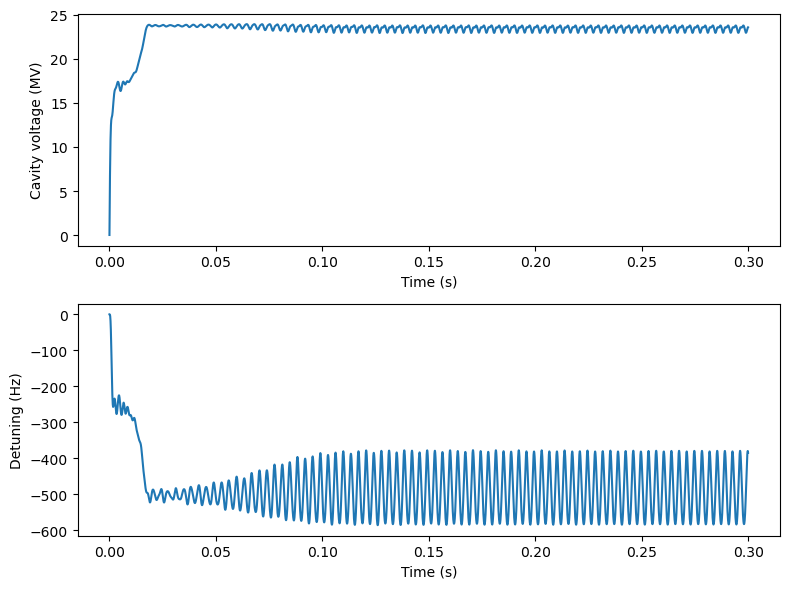

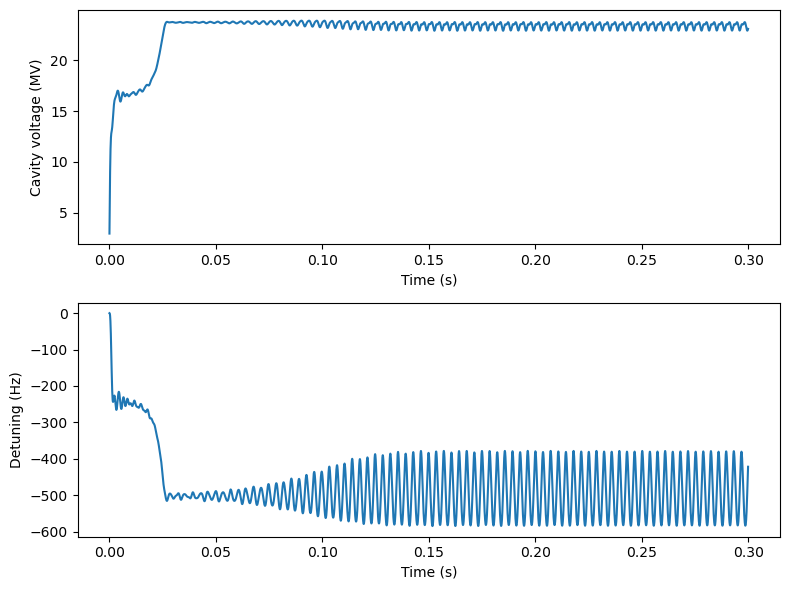

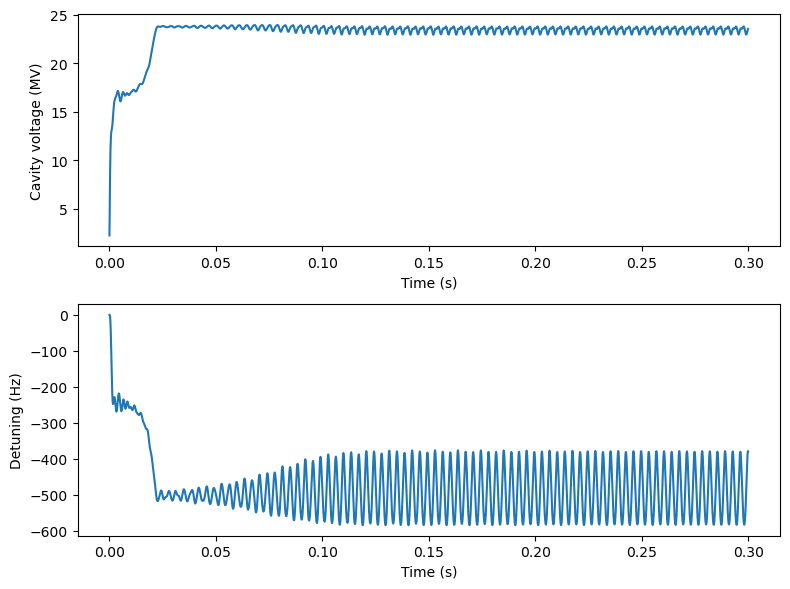

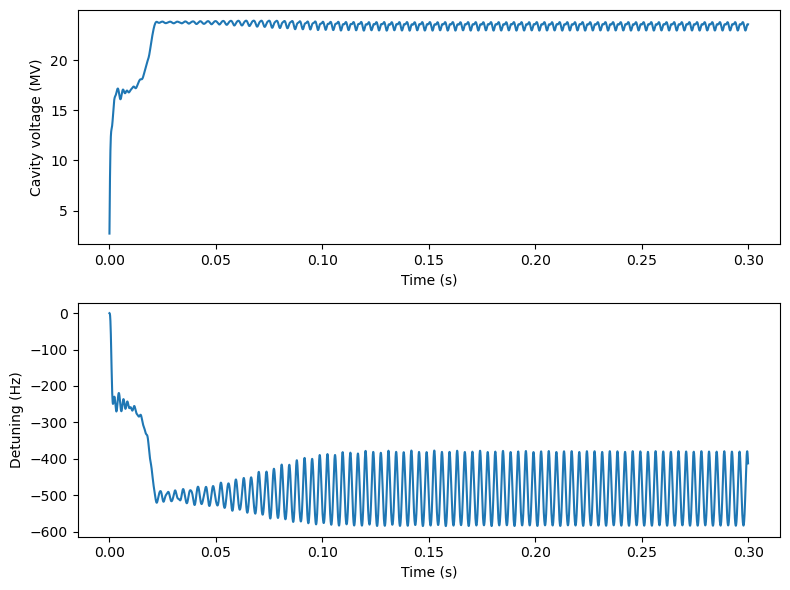

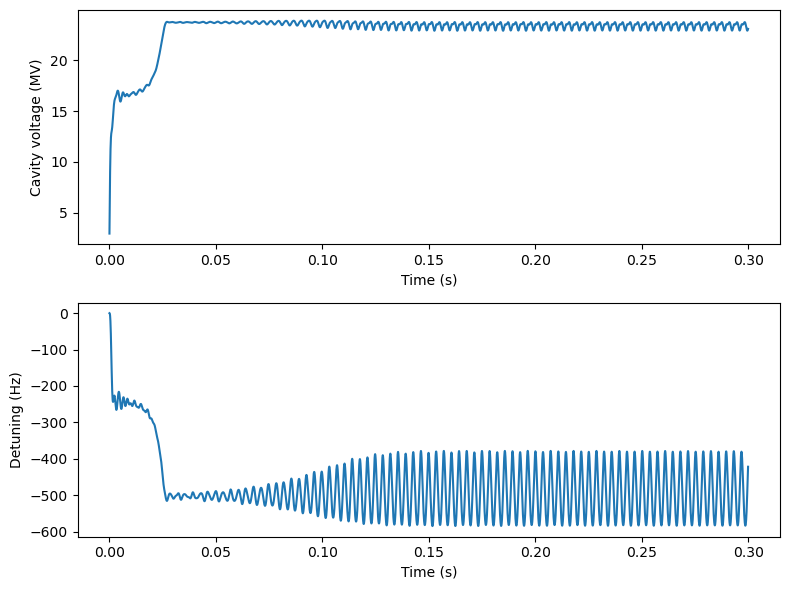

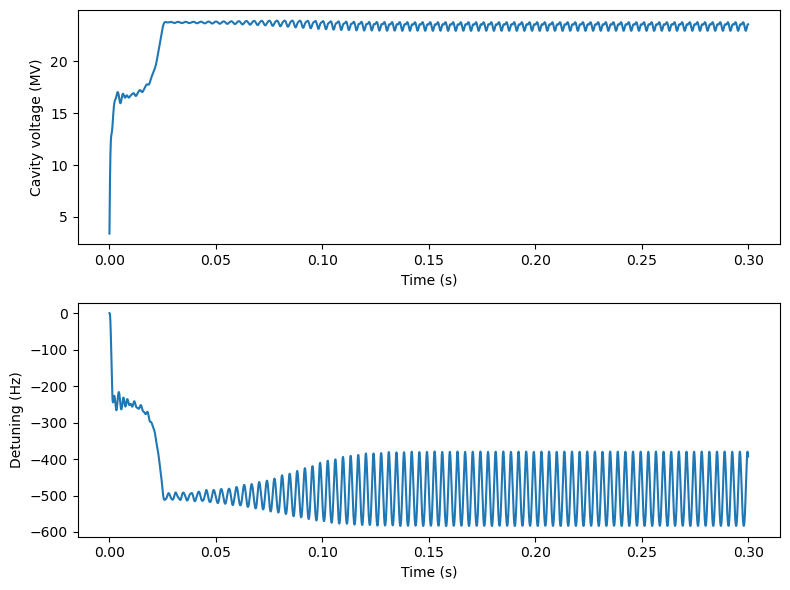

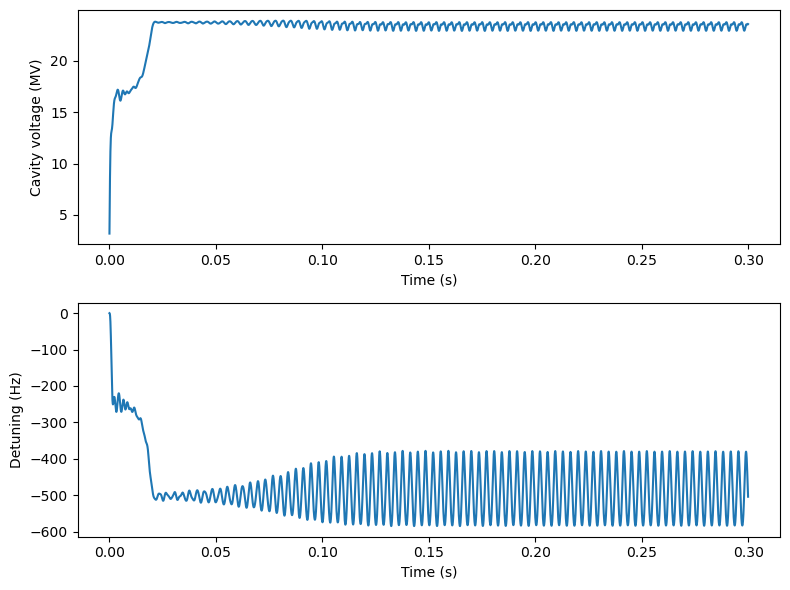

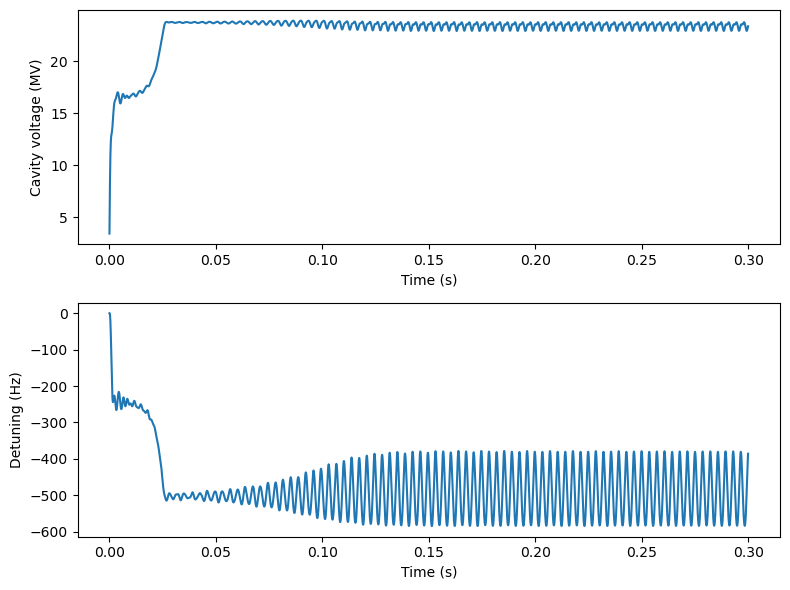

In [5]:
# --! display results im time domain --!

for vc, dc in zip(vcs, dcs):
    plot_result_timedomain(vc, dc, sim_nsample, sim_args.step_t, downsample=sim_o_downsample)

### Perform data post-processing

In [6]:
# --! process data into windows --!

def extract_windows(data, back_nsample, fore_nsample):

    windows = []

    data_nsample = data.shape[1]
    for d in data:
        for i in range(data_nsample):
            window_start = i - back_nsample
            window_end = i + fore_nsample
            if window_start >= 0 and window_end <= data_nsample:
                window = d[window_start:window_end, :]
                windows.append(window)

    return np.stack(windows)

vcs = np.stack(vcs)
dcs = np.stack(dcs)
data = np.concatenate([vcs, dcs], axis=-1)
print(f'inf > simulated data shape is {data.shape}')

# --! duplicate the first chunk of trajectory that contains cavity fold dynamics
ndup = 6
data = np.array_split(data, 6, axis=1)
data[0] = np.tile(data[0], (ndup,1,1))
data = np.concatenate(data, axis=0)

print(f'inf > split data shape is {data.shape}')

fore_nsample = 24
back_nsample = 2 * fore_nsample
windows = extract_windows(data, back_nsample, fore_nsample)
print(f'inf > extracted windows shape is {windows.shape}')

inf > simulated data shape is (8, 6000, 2)
inf > split data shape is (88, 1000, 2)
inf > extracted windows shape is (81752, 72, 2)


### Save data

In [7]:
datasaved = True

if datasaved:
    util_data.write_datafile(f'{data_dir}/windows', windows)
    print(f'inf > extracted windows saved')
    util_data.write_datafile(f'{data_dir}/trajectories', data)
    print(f'inf > extracted trajectories saved')

inf > extracted windows saved
inf > extracted trajectories saved
